
# Tools vs Skills in Agentic AI

## Core Idea

**Tools = atomic capabilities an agent can call**  
**Skills = composed behaviors that use tools to accomplish a goal**

This separation is fundamental when designing scalable agent platforms and reusable AI workflows.

---

## Tools (Building Blocks)

Tools are **single‑purpose functions** an agent can invoke. Think of them as structured APIs the agent can reason about.

**Examples**
- Send email
- Query database
- Call REST endpoint
- Execute Python code
- Web search
- Retrieve vector memory

**Key properties**
- Well defined input/output schema
- No independent reasoning
- No long‑term memory
- Narrow responsibility
- Deterministic behavior

**Example**
```
get_weather(city="Los Angeles") → 72°F
```

The agent decides *when* to use the tool.  
The tool never decides *what* to do.

---

## Skills (Higher Level Capabilities)

Skills are **goal‑oriented workflows** combining:

- Reasoning
- Multiple tool calls
- Memory/state (optional)
- Business logic
- Reusable orchestration patterns

They are essentially **reusable AI workflows**.

**Example skill: Trip Planning**

Workflow:
1. Search flights (tool)
2. Check weather (tool)
3. Find hotels (tool)
4. Optimize itinerary (reasoning)
5. Produce recommendation

A skill:
- Encapsulates problem solving
- Can be reused across domains
- Often includes decision making
- Operates at business abstraction level

---

## Key Differences

| Aspect | Tools | Skills |
|--------|-------|--------|
| Level | Low level | High level |
| Purpose | Do one thing | Achieve a goal |
| Logic | Minimal | Workflow & strategy |
| Composition | Independent | Built from tools |
| Reuse | Technical reuse | Business reuse |
| Example | send_email() | Customer follow‑up workflow |

---

## How They Work Together

Agent systems typically follow this pattern:

**User Goal**
→ "Book a business trip"

**Agent selects skill**
→ Travel planning skill

**Skill orchestrates tools**
→ Flight API  
→ Calendar API  
→ Payment API  
→ Notification tool

**Mental Model**

Skills decide **what to do**  
Tools execute **how to do it**

---

## Helpful Analogy

**Tools = muscles**  
**Skills = learned movements**

You don't think about contracting individual muscles when throwing a ball.  
You execute a learned skill that coordinates them.

Agents work the same way.

---

## Why This Separation Matters

This design enables:

**Modularity**
Swap tools without rewriting workflows

**Scalability**
Add new skills without changing the core agent

**Maintainability**
Clear separation of responsibilities

**Better reasoning**
Agents operate at the right abstraction level

**Enterprise readiness**
Maps cleanly to capability architecture patterns

---

## Design Rule

A practical rule:

**Tool = capability**  
**Skill = workflow**

In LangGraph and similar frameworks:
- Tools = nodes
- Skills = graphs
- Agents = orchestrators

---

## Architecture Perspective (Enterprise View)

This model maps cleanly to enterprise architecture:

Tools → Technical capabilities  
Skills → Business capabilities  
Agent → Cognitive orchestration layer

This is why modern agent platforms resemble:
- Workflow engines
- Capability registries
- Tool marketplaces
- Execution runtimes

---

## Takeaway

The most scalable agent platforms treat:

**Tools as infrastructure**
**Skills as reusable intelligence**

This is the difference between:
Building agents…  
and building an **agent platform**.


In [ ]:
!pip install langchain
!pip install langchain-core
!pip install langchain-community
!pip install langchain-ollama





[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [12]:
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain_ollama import ChatOllama

# 1) Tool: a small atomic capability
@tool
def get_order_status(order_id: str) -> str:
    """Look up the status of an order by ID."""
    # Replace with DB/API call
    return f"Order {order_id} is packed and ready to ship."

# 2) Another tool
@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email."""
    # Replace with real email integration
    return f"Sent email to {to} with subject: {subject}"

# 3) Skill: a higher-level workflow you define in your app
# "Customer order follow-up" is a skill built from tools + orchestration.
def customer_order_follow_up(order_id: str, customer_email: str) -> str:
    status = get_order_status.invoke({"order_id": order_id})
    email_result = send_email.invoke(
        {
            "to": customer_email,
            "subject": f"Update on your order {order_id}",
            "body": f"Hi! Here is your latest order status: {status}",
        }
    )
    return email_result


# 4) Agent: lets the model choose among tools
llm = ChatOllama(model="llama3.1")

agent = create_agent(
    model=llm,
    tools=[get_order_status, send_email],
)


# Example agent call
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Check order 123 and email the customer."}]}
)

print(result)

{'messages': [HumanMessage(content='Check order 123 and email the customer.', additional_kwargs={}, response_metadata={}, id='d132dbd3-fa82-489f-b243-eafb6800c26b'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-03-25T21:27:00.607694Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5908321916, 'load_duration': 3555421291, 'prompt_eval_count': 206, 'prompt_eval_duration': 1287213584, 'eval_count': 58, 'eval_duration': 1040782462, 'logprobs': None, 'model_name': 'llama3.1', 'model_provider': 'ollama'}, id='lc_run--019d26e4-afd9-7662-8dea-fa4ca2a2377c-0', tool_calls=[{'name': 'get_order_status', 'args': {'order_id': '123'}, 'id': '54b3722d-5bba-481f-8699-5319faa81bb8', 'type': 'tool_call'}, {'name': 'send_email', 'args': {'subject': 'Order Status Update', 'body': 'Your order #123 has been processed.', 'to': 'customer@example.com'}, 'id': '19c23115-d9e0-48c1-92bd-cabaf0aeca10', 'type': 'tool_call'}], invalid_tool_calls=[], 

How this maps conceptually:

get_order_status and send_email are tools: narrow, reusable actions. 
customer_order_follow_up is a skill: a business workflow that orchestrates multiple steps.
agent = create_agent(...) lets the model decide when to call the tools in a loop. 
A good rule of thumb is: if it is one action, make it a tool; if it is a repeatable business process, make it a skill built on tools. 

In [3]:
from typing import TypedDict
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END

@tool
def get_order_status(order_id: str) -> str:
    """Look up the status of an order by ID."""
    # Replace with DB/API call
    return f"Order {order_id} is packed and ready to ship."

@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email."""
    # Replace with real email integration
    return f"Sent email to {to} with subject: {subject}"

# ---- Graph State ---
class State(TypedDict):
    order_id: str
    customer_email: str
    order_status: str
    email_result: str

# ------ Nodes: Orchestration + Tools ------
def lookup_order_node(state: State) -> State:
    status = get_order_status.invoke({"order_id": state["order_id"]})
    return {"order_status": status}

def should_email_node(state: State) -> bool:
    return state["order_status"] == "packed and ready to ship"

def email_customer_node(state: State) -> State:
    email_result = send_email.invoke(
        {
            "to": state["customer_email"],
            "subject": f"Update on your order {state['order_id']}",
            "body": f"Hi! Here is your latest order status: {state['order_status']}",
        }
    )
    return {"email_result": email_result}

# ---- Skill : the workflow graph ----
builder = StateGraph(State)
builder.add_node("lookup_order", lookup_order_node)
builder.add_node("email_customer", email_customer_node)

builder.add_edge(START, "lookup_order")
builder.add_conditional_edges(
    "lookup_order",
    should_email_node,
    {
        True: "email_customer",
        False: END, 
    },
)

builder.add_edge("email_customer", END)

graph = builder.compile()

# Execute the graph with initial state
result = graph.invoke({"order_id": "123", "customer_email": "customer@example.com"})
print(result)


{'order_id': '123', 'customer_email': 'customer@example.com', 'order_status': 'Order 123 is packed and ready to ship.'}


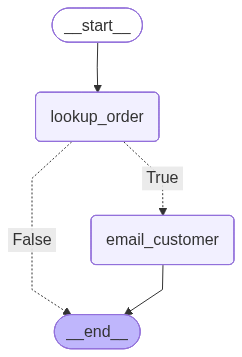

In [2]:
from IPython.display import Image, Markdown, display

# Visualize the compiled LangGraph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    mermaid = graph.get_graph().draw_mermaid()
    print("PNG rendering failed. Showing Mermaid source instead:")
    print(mermaid)
    display(Markdown(f"```mermaid\n{mermaid}\n```"))


# Practical Examples

Below are three practical patterns that make the **tools vs skills** distinction concrete:

1. **LangGraph example** — a skill graph orchestrating tools  
2. **Memory example** — adding durable context to behavior  
3. **Multi-skill agent example** — routing user requests to the right skill  

These examples are intentionally simple so they can be adapted into production architectures later.



## 1) Clean LangGraph Example: Tool + Skill Graph

In this example:

- **Tools** are atomic functions:
  - `search_docs`
  - `send_email`
- **Skill** is the workflow:
  - understand request
  - gather information
  - generate a response
  - optionally send the response

This is the key idea:

- **Tools = execution primitives**
- **Graph = skill definition**
- **Agent = orchestrator**


In [4]:

# pip install langgraph langchain-core pydantic

from typing import TypedDict, List, Optional
from langgraph.graph import StateGraph, END


# ---------------------------
# Tools (atomic capabilities)
# ---------------------------

def search_docs(query: str) -> str:
    return f"Found internal notes relevant to: {query}"

def send_email(to: str, subject: str, body: str) -> str:
    return f"Email sent to {to} with subject '{subject}'"


# ---------------------------
# Skill state
# ---------------------------

class FollowUpState(TypedDict, total=False):
    user_request: str
    customer_email: str
    notes: str
    draft_response: str
    send_now: bool
    result: str


# ---------------------------
# Skill nodes
# ---------------------------

def gather_context(state: FollowUpState) -> FollowUpState:
    notes = search_docs(state["user_request"])
    return {"notes": notes}

def draft_message(state: FollowUpState) -> FollowUpState:
    response = (
        f"Hello,\n\n"
        f"Based on your request, here is the follow-up.\n"
        f"Context used: {state['notes']}\n\n"
        f"Regards"
    )
    return {"draft_response": response}

def decide_send(state: FollowUpState) -> str:
    return "send" if state.get("send_now") else "end"

def send_message(state: FollowUpState) -> FollowUpState:
    result = send_email(
        to=state["customer_email"],
        subject="Follow-up",
        body=state["draft_response"],
    )
    return {"result": result}


# ---------------------------
# Build graph = skill
# ---------------------------

graph = StateGraph(FollowUpState)

graph.add_node("gather_context", gather_context)
graph.add_node("draft_message", draft_message)
graph.add_node("send_message", send_message)

graph.set_entry_point("gather_context")
graph.add_edge("gather_context", "draft_message")
graph.add_conditional_edges(
    "draft_message",
    decide_send,
    {
        "send": "send_message",
        "end": END,
    },
)
graph.add_edge("send_message", END)

follow_up_skill = graph.compile()


# ---------------------------
# Run the skill
# ---------------------------

result = follow_up_skill.invoke(
    {
        "user_request": "Need to follow up with customer about renewal options",
        "customer_email": "customer@example.com",
        "send_now": False,
    }
)

result


{'user_request': 'Need to follow up with customer about renewal options',
 'customer_email': 'customer@example.com',
 'notes': 'Found internal notes relevant to: Need to follow up with customer about renewal options',
 'draft_response': 'Hello,\n\nBased on your request, here is the follow-up.\nContext used: Found internal notes relevant to: Need to follow up with customer about renewal options\n\nRegards',
 'send_now': False}


### Why this example matters

This graph is the **skill**.  
The functions like `search_docs()` and `send_email()` are the **tools**.

You can swap:
- the search tool
- the messaging tool
- even the LLM

without rewriting the overall business workflow.



## 2) Memory Example

Memory is what allows an agent to behave with continuity over time.

A skill may need to remember:
- user preferences
- prior interactions
- business context
- unfinished tasks
- frequently used entities

Important distinction:

- A **tool** can read/write memory
- A **skill** decides when memory matters
- The **agent** uses memory to personalize decisions

Below is a lightweight example using simple in-memory storage.


In [5]:

from typing import Dict, Any


# ---------------------------
# Memory store
# ---------------------------

class MemoryStore:
    def __init__(self):
        self.store: Dict[str, Dict[str, Any]] = {}

    def save(self, user_id: str, key: str, value: Any) -> None:
        self.store.setdefault(user_id, {})[key] = value

    def load(self, user_id: str, key: str, default=None) -> Any:
        return self.store.get(user_id, {}).get(key, default)


memory = MemoryStore()


# ---------------------------
# Memory tools
# ---------------------------

def save_preference(user_id: str, key: str, value: Any) -> str:
    memory.save(user_id, key, value)
    return f"Saved {key} for {user_id}"

def get_preference(user_id: str, key: str) -> Any:
    return memory.load(user_id, key)


# ---------------------------
# Skill that uses memory
# ---------------------------

def recommend_trip(user_id: str, destination: str) -> str:
    seat = get_preference(user_id, "seat_preference")
    hotel_style = get_preference(user_id, "hotel_style")

    return (
        f"Trip recommendation for {destination}:\n"
        f"- Preferred airline seat: {seat or 'not set'}\n"
        f"- Preferred hotel style: {hotel_style or 'not set'}\n"
        f"- Next step: search flights and hotels matching these preferences"
    )


# ---------------------------
# Example usage
# ---------------------------

print(save_preference("arif", "seat_preference", "aisle"))
print(save_preference("arif", "hotel_style", "family friendly"))

print()
print(recommend_trip("arif", "Istanbul"))


Saved seat_preference for arif
Saved hotel_style for arif

Trip recommendation for Istanbul:
- Preferred airline seat: aisle
- Preferred hotel style: family friendly
- Next step: search flights and hotels matching these preferences



### Memory design insight

Memory should usually be treated as a **platform capability**, not hidden inside a single tool.

In production systems, memory may include:
- short-term conversation state
- long-term user profile
- semantic memory in a vector database
- structured state in SQL/NoSQL
- audit/event history

That means memory itself can be implemented through tools such as:
- `read_profile`
- `save_preference`
- `retrieve_similar_cases`
- `load_session_state`

Then skills decide how to use that memory.



## 3) Multi-Skill Agent Example

A mature agent platform usually does not have just one skill.

Instead, it has:
- a **set of skills**
- a **routing layer**
- shared tools
- shared memory
- policy and observability

Example skills:
- Travel planning
- Customer follow-up
- Meeting scheduling

The agent’s job is not to do everything directly.  
Its job is to **select the right skill** for the user’s goal.


In [6]:

from typing import Callable


# ---------------------------
# Individual skills
# ---------------------------

def travel_planning_skill(request: str) -> str:
    return (
        "Travel Planning Skill selected\n"
        "- Search flights\n"
        "- Check hotels\n"
        "- Review weather\n"
        "- Build itinerary"
    )

def customer_followup_skill(request: str) -> str:
    return (
        "Customer Follow-up Skill selected\n"
        "- Retrieve account notes\n"
        "- Draft follow-up\n"
        "- Send or queue email"
    )

def schedule_meeting_skill(request: str) -> str:
    return (
        "Meeting Scheduling Skill selected\n"
        "- Check calendar\n"
        "- Find available slots\n"
        "- Send invite"
    )


# ---------------------------
# Simple skill router
# ---------------------------

def route_skill(request: str) -> Callable[[str], str]:
    text = request.lower()

    if "trip" in text or "flight" in text or "hotel" in text:
        return travel_planning_skill
    elif "follow up" in text or "customer" in text or "email" in text:
        return customer_followup_skill
    elif "meeting" in text or "calendar" in text or "schedule" in text:
        return schedule_meeting_skill
    else:
        return lambda req: "No matching skill found. Escalate to general reasoning agent."


# ---------------------------
# Agent entry point
# ---------------------------

def agent(request: str) -> str:
    skill = route_skill(request)
    return skill(request)


# ---------------------------
# Example usage
# ---------------------------

requests = [
    "Book me a business trip to New York next week",
    "Follow up with customer about the renewal contract",
    "Schedule a meeting with engineering leadership",
]

for r in requests:
    print(f"Request: {r}")
    print(agent(r))
    print("-" * 60)


Request: Book me a business trip to New York next week
Travel Planning Skill selected
- Search flights
- Check hotels
- Review weather
- Build itinerary
------------------------------------------------------------
Request: Follow up with customer about the renewal contract
Customer Follow-up Skill selected
- Retrieve account notes
- Draft follow-up
- Send or queue email
------------------------------------------------------------
Request: Schedule a meeting with engineering leadership
Meeting Scheduling Skill selected
- Check calendar
- Find available slots
- Send invite
------------------------------------------------------------



### Architecture takeaway

A multi-skill agent platform typically looks like this:

**User request**  
→ intent detection / routing  
→ select skill  
→ skill orchestrates tools  
→ memory enriches execution  
→ guardrails + logging observe the run

This is also why many enterprise agent platforms evolve into:

- tool registries
- skill registries
- execution runtimes
- memory services
- policy and governance layers



## Final Summary

A practical hierarchy looks like this:

- **Tool** → atomic capability
- **Skill** → reusable workflow built from tools
- **Agent** → orchestrator that selects and executes skills
- **Platform** → runtime that manages tools, skills, memory, policies, and observability

That layered model is what makes agent systems maintainable and enterprise-ready.
